# Monetary IRFs from US Data

This code imports FRED data for monetary policy IRFs with US data and then analyzes IRFs for a monetary policy shock using VAR, LP, and SLP. The variables used are the [federal funds effective rate](https://fred.stlouisfed.org/series/DFF#), [real GDP](https://fred.stlouisfed.org/series/GDPC1), and [personal consumption expenditures](https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA). Data is from Jan 2012 - Oct 2025.

In [134]:
# append the path of the parent directory to import slp modules
import sys
sys.path.append("..")

# import packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

# import slp module
from slp.estimators import SmoothLocalProjections

In [135]:
# set parameters
q = 12 # number of quarters for IRFs

In [136]:
# IRF plotting function
def plot_irf(data, title):
    data.rename(columns={0: 'GDP', 1: 'Inflation', 2: 'FFR'}, inplace=True)
    varnames = data.columns
    plt.figure(figsize=(12, 8))
    for i in range(3):
        plt.subplot(2, 3, i+1)
        plt.plot(data[varnames[i]])
        plt.title(f'FFR -> {varnames[i]}')
        plt.xlabel('Quarters')
        plt.ylabel('Response')
        plt.axhline(0, color='black', linestyle='dashed')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

### Loading, processing, and visualizing data

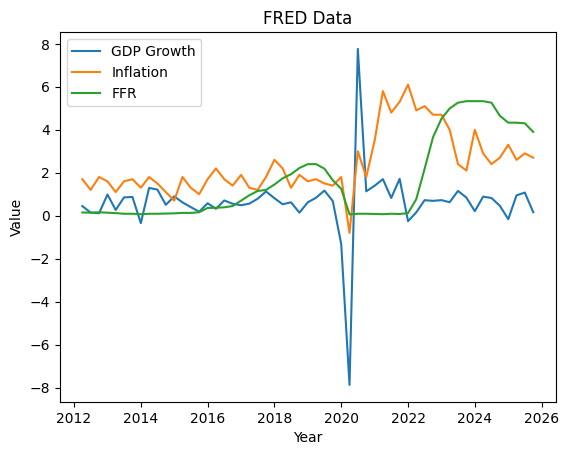

In [137]:
# load data
gdp = pd.read_csv('../example_notebooks/monetary_example_data/GDPC1.csv', index_col=0, parse_dates=True)
pce = pd.read_csv('../example_notebooks/monetary_example_data/DPCCRV1Q225SBEA.csv', index_col=0, parse_dates=True)
ffr = pd.read_csv('../example_notebooks/monetary_example_data/DFF.csv', index_col=0, parse_dates=True)

# merge data into one dataframe
data = pd.concat([gdp, pce, ffr], axis=1)
data.columns = ['GDP','Inflation', 'FFR']

# GDP growth rate
data['GDP'] = data['GDP'].pct_change() * 100
data = data.dropna() # removes first observations (missing differences)

# plot observed time series
plt.plot(data)
plt.title("FRED Data")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend(["GDP Growth", "Inflation", "FFR"])
plt.show()

### Estimating IRFs using VAR

AIC optimal lags: 4


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


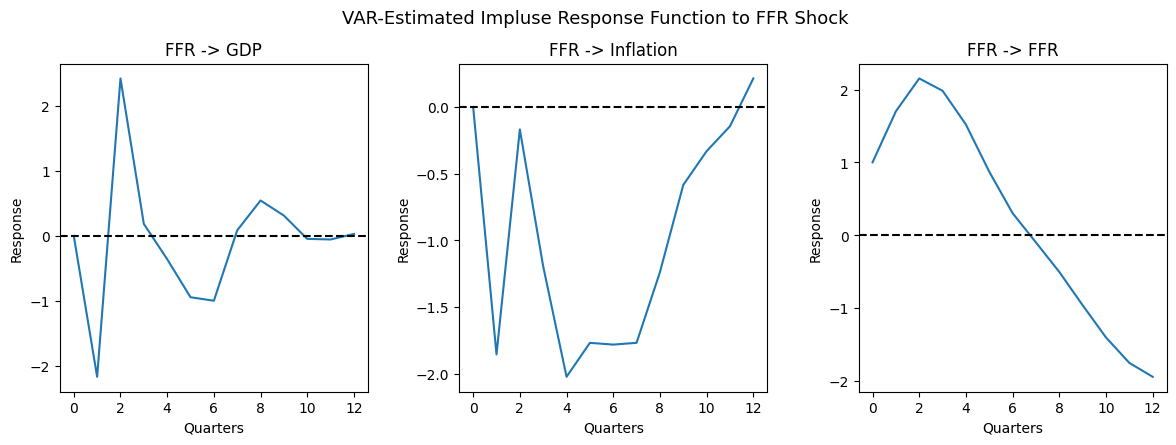

In [138]:
# VAR estimation of IRFs
model = VAR(data)
results = model.fit(ic="aic")
irfs = results.irf(periods=q).orth_irfs / np.diag(results.irf(periods=q).P)[2] # orthogonalized IRFs scaled to unit FFR shock for consistency
var = pd.DataFrame(irfs[:,:,2])

print("AIC optimal lags:", model.select_order(maxlags=10).aic) # optimal lags from AIC - used for VAR, LP, and SLP estimation

plot_irf(var, 'VAR-Estimated Impluse Response Function to FFR Shock')

### Estimating IRFs using local projections

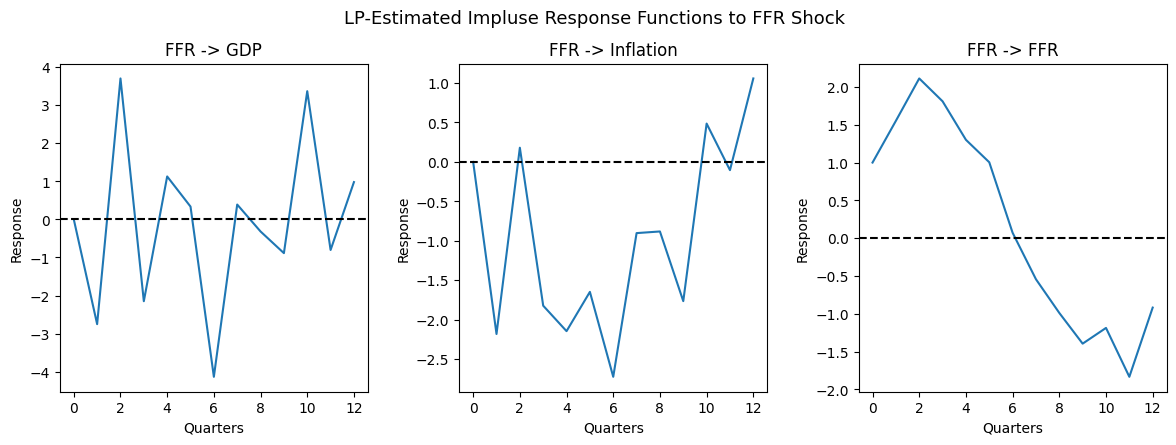

In [139]:
# LP estimation of IRFs
LP_model = SmoothLocalProjections(data, "FFR", None, False, 4, q) # same lags as VAR
LP = pd.DataFrame(LP_model.LP().beta)

plot_irf(LP, 'LP-Estimated Impluse Response Functions to FFR Shock')

### Estimating IRFs using smooth local projections

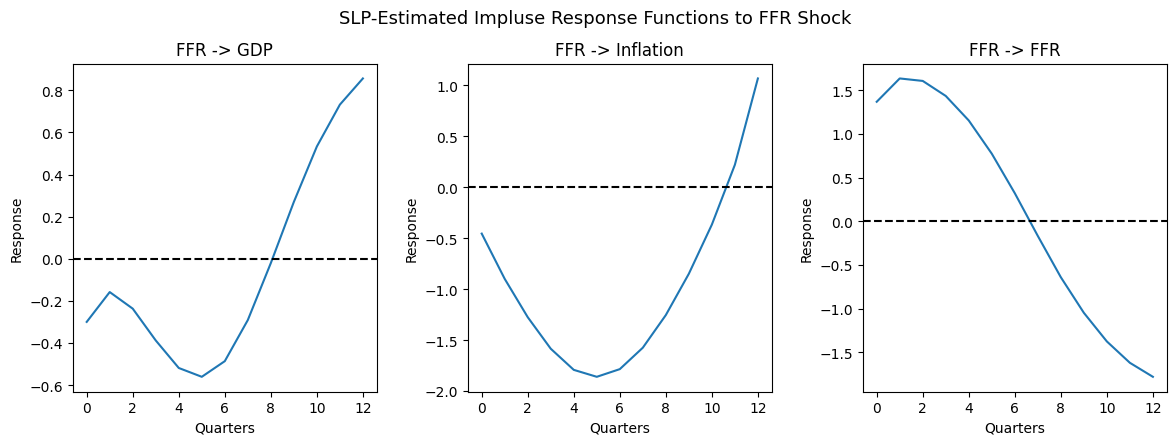

In [140]:
# SLP estimation of IRFs
SLP_model = SmoothLocalProjections(data, "FFR", None, False, 4, q) # same lags as VAR
SLP = pd.DataFrame(SLP_model.SLP().beta)

plot_irf(SLP, 'SLP-Estimated Impluse Response Functions to FFR Shock')

### Discussion

### Data Citations
Board of Governors of the Federal Reserve System (US), Federal Funds Effective Rate [DFF], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DFF, April 4, 2026.
U.S. Bureau of Economic Analysis, Personal Consumption Expenditures (PCE) Excluding Food and Energy (Chain-Type Price Index) [DPCCRV1Q225SBEA], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DPCCRV1Q225SBEA, April 4, 2026.
U.S. Bureau of Economic Analysis, Real Gross Domestic Product [GDPC1], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/GDPC1, April 4, 2026.
U.S. Bureau of Labor Statistics, Unemployment Rate [UNRATE], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/UNRATE, April 4, 2026.